### Amanda Cutler
### Assignment 5

Note to grader: I have already done the Part 1 exercises in another class for Assignment 2 in Special Topics in Earth and Environmental Engineering, hence why it looks a little different than the xx.shape,yy.shape syntax we learned in class


### 1 Creating and Manipulating Arrays
First import numpy and matplotlib

1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
Both should cover the range (-2, 2) and have 100 points in each direction

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
n = 100
x = np.linspace(-2,2,n)
y = np.linspace(-2,2,n)

X,Y=np.meshgrid(x,y,indexing='xy')
X.shape, Y.shape

1.2. Visualize each 2D array using pcolormesh
Use the correct coordiantes for the x and y axes.

In [ ]:
fig,ax=plt.subplots()
pcm=ax.pcolormesh(X,Y,X,shading='auto')
ax.set_title('2D Array X Values on XY Plane')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pcm,ax=ax,label='X')
plt.show()

fig,ax=plt.subplots()
pcm=ax.pcolormesh(X,Y,Y,shading='auto')
ax.set_title('2D Array Y Values on XY Plane')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pcm,ax=ax,label='Y')
plt.show()
                 

1.3 From your cartesian coordinates, create polar coordinates. Refer to the wikipedia page for the conversion formula. You will need to use numpy’s arctan2 function. Read its documentation.

In [22]:
#radius r = x^2 + y^2

r = np.sqrt(X**2 + Y**2)

#theta = arctan2 (y, x)

theta = np.arctan2(Y,X)

r.shape, theta.shape, (r.min(), r.max()), (theta.min(),theta.max())

((100, 100),
 (100, 100),
 (0.028569970957032093, 2.8284271247461903),
 (-3.1314919870044715, 3.131491987004471))

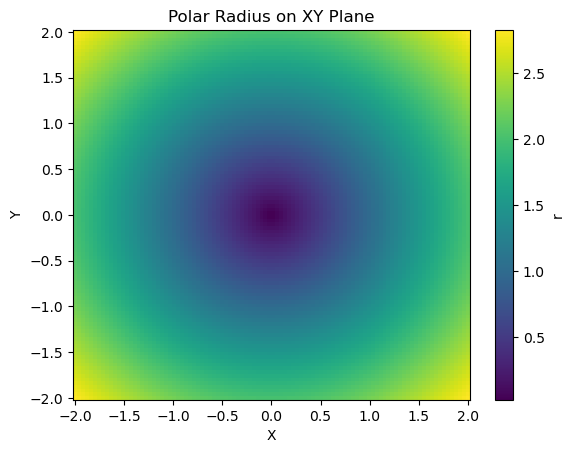

In [23]:
fig,ax=plt.subplots()
pcm=ax.pcolormesh(X,Y,r,shading='auto')
ax.set_title('Polar Radius on XY Plane')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pcm,ax=ax,label='r')
plt.show()

1.4. Visualize r and theta on the 2D x/y plane using pcolormesh

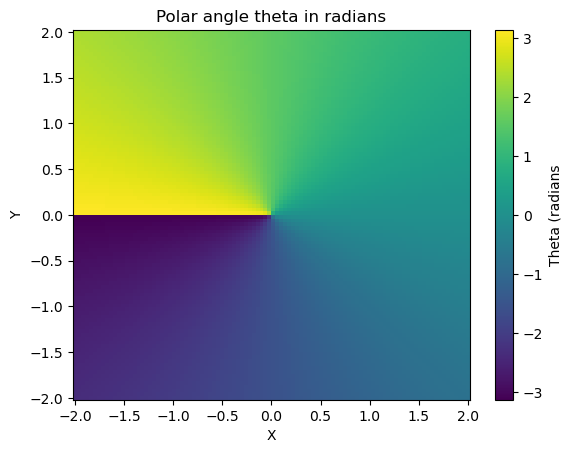

In [24]:
fig,ax=plt.subplots()
pcm=ax.pcolormesh(X,Y,theta,shading='auto')
ax.set_title('Polar angle theta in radians')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pcm,ax=ax,label='Theta (radians')
plt.show()

1.5 Caclulate the quanity and plot it on the x/y plane

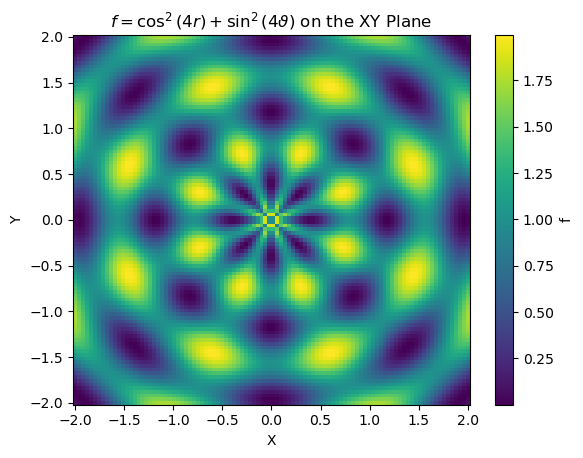

(0.0007241747082744095, 1.9937332825781462)

In [25]:
f=np.cos(4*r)**2 + np.sin(4*theta)**2

fig,ax=plt.subplots()
pcm=ax.pcolormesh(X,Y,f,shading='auto')
ax.set_title(r'$f= \cos^2(4r) + \sin^2(4\vartheta)$ on the XY Plane')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(pcm,ax=ax,label='f')
plt.show()

f.min(),f.max()

### Analyze ARGO Data

In [3]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

2.1 Load each data file as a numpy array.
You can use whatever names you want for your arrays, but I recommend

T: temperature

S: salinity

P: pressure

date: date

lat: latitude

lon: longitude

level: depth level

Note: you have to actually look at the file name (the items in files) to know which files corresponds to which variable.

In [4]:
#Date
date=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy')
#Temperature
T=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy')
#Salinity
S=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy')
#Pressure
P=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy')
#Depth levels
levels=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy')
#Longitude
lon=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy')
#Latitude
lat=np.load('/home/alc2282/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy')


2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?
Based on the shapes, which dimensions do you think are shared among the arrays?

In [5]:
T.shape, S.shape, P.shape, lon.shape, date.shape, levels.shape

((78, 75), (78, 75), (78, 75), (75,), (75,), (78,))

Based on the depth levels being 78 rows, which is the first position in Temperature, Shape, and Pressure, I think that T, S, and P are measured at each depth level, producing 78 rows. With Lat, Lon, and Date being 75 rows, I think that the 75 columns in T, S, and P are the 75 dates/locations at which T, S, and P are measured at each of the 78 depth levels.

2.3 Make a plot for each column of data in T, S and P (three plots).
The vertical scale should be the levels data. Each plot should have a line for each column of data. It will look messy.

Text(0.5, 1.0, 'All Temperature Profiles at Each Date/Location')

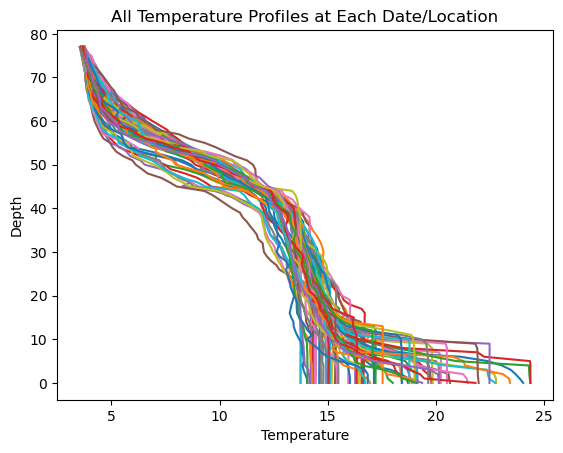

In [6]:
plt.figure()
plt.plot(T,levels)
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.title('All Temperature Profiles at Each Date/Location')

Text(0.5, 1.0, 'All Salinity Profiles at Each Date/Location')

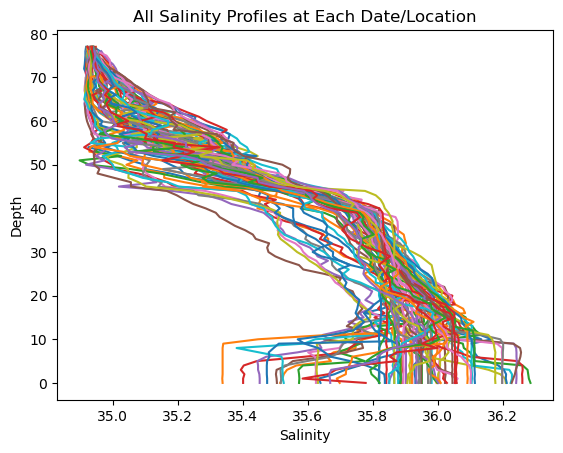

In [47]:
plt.figure()
plt.plot(S,levels)
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.title('All Salinity Profiles at Each Date/Location')

Text(0.5, 1.0, 'Pressure vs. Depth')

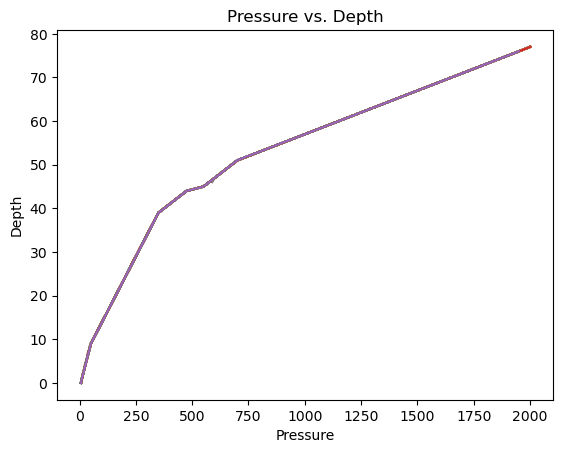

In [7]:
plt.figure()
plt.plot(P,levels)
plt.xlabel('Pressure')
plt.ylabel('Depth')
plt.title('Pressure vs. Depth')

2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [8]:
#see if nans are present
T

array([[18.97400093, 18.43700027, 19.09900093, ..., 19.11300087,
        21.82299995, 20.13100052],
       [18.74099922, 18.39999962, 19.08200073, ..., 18.47200012,
        19.45999908, 20.125     ],
       [18.37000084, 18.37400055, 19.06500053, ..., 18.22999954,
        19.26199913, 20.07699966],
       ...,
       [ 3.79299998,  3.81399989,  3.80200005, ...,  3.80699992,
         3.81100011,  3.8599999 ],
       [ 3.76399994,  3.77800012,  3.75699997, ...,  3.75399995,
         3.74600005,  3.80599999],
       [ 3.74399996,  3.74600005,  3.7249999 , ...,         nan,
         3.71399999,         nan]])

In [9]:
#without considering nan values

T_mean=np.mean(T,axis=1)
T_std=np.std(T,axis=1)

S_mean=np.mean(S,axis=1)
S_std=np.std(S,axis=1)

P_mean=np.mean(P,axis=1)
P_std=np.std(P,axis=1)

In [10]:
T_mean, T_std

(array([        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan, 10.80430666, 10.49702667, 10.1749066 ,  9.83453334,
         9.48625332,  9.19793334,  8.66010666,  8.12324001,  7.60221333,
         7.15289333,  6.74250667,  6.39543999,  6.04598667,  5.74538665,
         5.48913333,  5.26604001,  5.08768   ,  4.93479998,  4.77769334,
         4.65368   ,  4.54237334,  4.44274664,  4.3

In [11]:
S_mean, S_std

(array([        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan, 35.41392634, 35.3810557 , 35.34845245, 35.31531555,
        35.28392568, 35.26568334, 35.2389473 , 35.21583745, 35.19686081,
        35.18231257, 35.1648436 , 35.15073542, 35.12509338, 35.10155869,
        35.08199799, 35.06317012, 35.0490097 , 35.03678253, 35.02174266,
        35.01135579, 35.00212936, 34.99386297, 34.9

In [12]:
P_mean, P_std

(array([   6.43466671,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,           nan,           nan,
                  nan,           nan,  575.68400146,  600.42400716,
         625.30800456,  650.34533773,  675.33333984,  700.37067546,
         750.42400716,  800.36666992,  850.38534017,  900.4613387 ,
         950.45067383, 1000.38534261, 1050.38534

2.5 Now make three similar plots, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

Text(0.5, 1.0, 'Mean Temperature at Each Depth')

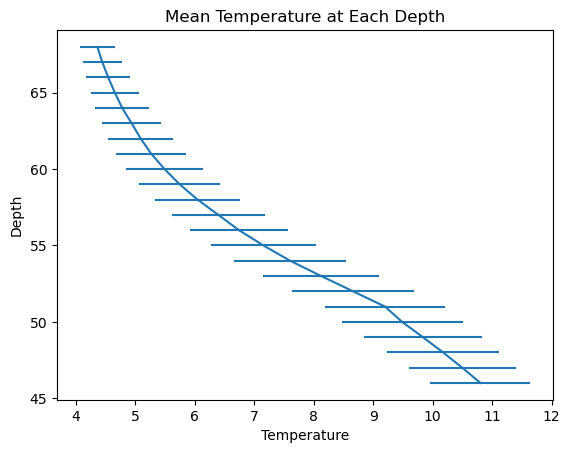

In [13]:
plt.figure()
plt.errorbar(T_mean,levels,xerr=T_std)
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.title('Mean Temperature at Each Depth')

Text(0.5, 1.0, 'Mean Salinity at Each Depth')

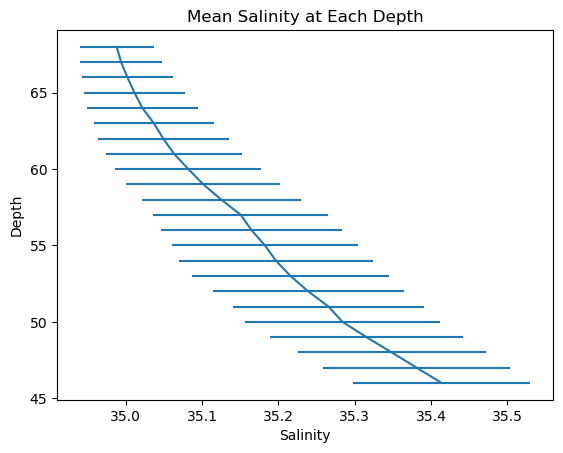

In [14]:
plt.figure()
plt.errorbar(S_mean,levels,xerr=S_std)
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.title('Mean Salinity at Each Depth')


Text(0.5, 1.0, 'Mean Pressure at Each Depth')

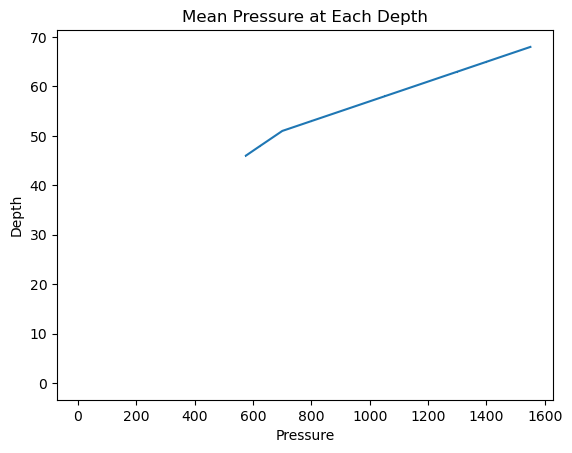

In [15]:
plt.figure()
plt.errorbar(P_mean,levels,xerr=P_std)
plt.xlabel('Pressure')
plt.ylabel('Depth')
plt.title('Mean Pressure at Each Depth')


2.6 Account For Missing Data The profiles contain many missing values. These are indicated by the special “Not a Number” value, or np.nan.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes NaN. Instead, if you use the special functions np.nanmean and np.nanstd, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

In [16]:
T_mean= np.nanmean(T, axis=1)
T_std= np.nanstd(T,axis=1)

S_mean=np.nanmean(S,axis=1)
S_std=np.nanstd(S,axis=1)

P_mean=np.nanmean(P,axis=1)
P_std=np.nanstd(P,axis=1)

#without considering nan values --> T_mean=np.mean(T,axis=1)

In [17]:
T_mean, T_std

(array([17.60172602, 17.57223609, 17.5145833 , 17.42326395, 17.24943838,
        17.03730134, 16.76787661, 16.44609588, 16.17439195, 16.04501356,
        15.65827023, 15.4607296 , 15.26114862, 15.12489191, 14.99133783,
        14.90160808, 14.81990544, 14.74535139, 14.66822971, 14.585027  ,
        14.49732434, 14.41904053, 14.35412163, 14.27102702, 14.19081082,
        14.11487838, 14.04347293, 13.98067566, 13.90994595, 13.83274319,
        13.76139196, 13.69836479, 13.62335132, 13.54185131, 13.46647295,
        13.39395946, 13.32541891, 13.25205403, 13.18131082, 13.10233782,
        12.89268916, 12.67795943, 12.4649189 , 12.2178513 , 11.98270268,
        11.1281081 , 10.80430666, 10.49702667, 10.1749066 ,  9.83453334,
         9.48625332,  9.19793334,  8.66010666,  8.12324001,  7.60221333,
         7.15289333,  6.74250667,  6.39543999,  6.04598667,  5.74538665,
         5.48913333,  5.26604001,  5.08768   ,  4.93479998,  4.77769334,
         4.65368   ,  4.54237334,  4.44274664,  4.3

In [18]:
S_mean, S_std

(array([35.9063218 , 35.90223138, 35.90313435, 35.90173139, 35.90544583,
        35.9100359 , 35.90946015, 35.91343146, 35.91967712, 35.92615988,
        35.93195456, 35.94055356, 35.94091596, 35.93905366, 35.93931069,
        35.93786745, 35.93525794, 35.93118039, 35.92534328, 35.91652257,
        35.90671895, 35.89617843, 35.88888019, 35.8789927 , 35.86946183,
        35.8598671 , 35.85061713, 35.84211978, 35.83150467, 35.81969395,
        35.80945061, 35.80092265, 35.79078674, 35.77886525, 35.76833627,
        35.75838795, 35.74923783, 35.73923559, 35.73000444, 35.71877237,
        35.68864513, 35.65607159, 35.62678265, 35.59231774, 35.56205662,
        35.45401408, 35.41392634, 35.3810557 , 35.34845245, 35.31531555,
        35.28392568, 35.26568334, 35.2389473 , 35.21583745, 35.19686081,
        35.18231257, 35.1648436 , 35.15073542, 35.12509338, 35.10155869,
        35.08199799, 35.06317012, 35.0490097 , 35.03678253, 35.02174266,
        35.01135579, 35.00212936, 34.99386297, 34.9

In [19]:
P_mean, P_std

(array([   6.43466671,   10.56891882,   15.54246568,   20.46301361,
          25.42567552,   30.44459441,   35.44324375,   40.4391894 ,
          45.40810832,   50.37837879,   60.47297323,   70.48378413,
          80.40270347,   90.48243311,  100.51216311,  110.46081151,
         120.52702795,  130.49459282,  140.51216064,  150.40540376,
         160.40810559,  170.36216035,  180.41080949,  190.4108097 ,
         200.39999761,  210.34729499,  220.32026858,  230.31351224,
         240.28918808,  250.41486297,  260.39999843,  270.36891752,
         280.42432136,  290.42297075,  300.4229691 ,  310.46351087,
         320.50675346,  330.5297266 ,  340.41891521,  350.49729383,
         375.41080867,  400.3797294 ,  425.29864626,  450.38378205,
         475.30675403,  550.47703016,  575.68400146,  600.42400716,
         625.30800456,  650.34533773,  675.33333984,  700.37067546,
         750.42400716,  800.36666992,  850.38534017,  900.4613387 ,
         950.45067383, 1000.38534261, 1050.38534

Text(0.5, 1.0, 'Mean Temperature at Each Depth')

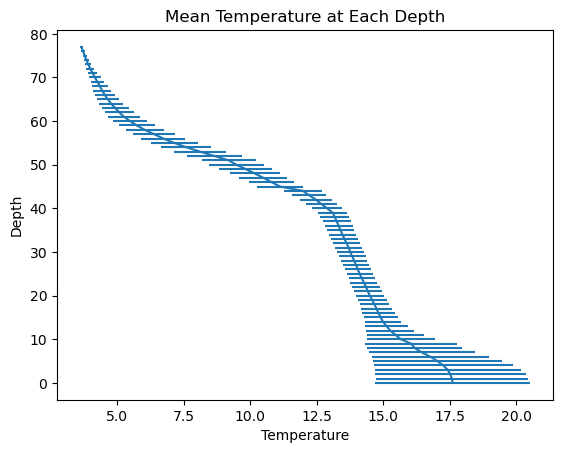

In [74]:
plt.figure()
plt.errorbar(T_mean,levels,xerr=T_std)
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.title('Mean Temperature at Each Depth')


Text(0.5, 1.0, 'Mean Salinity at Each Depth')

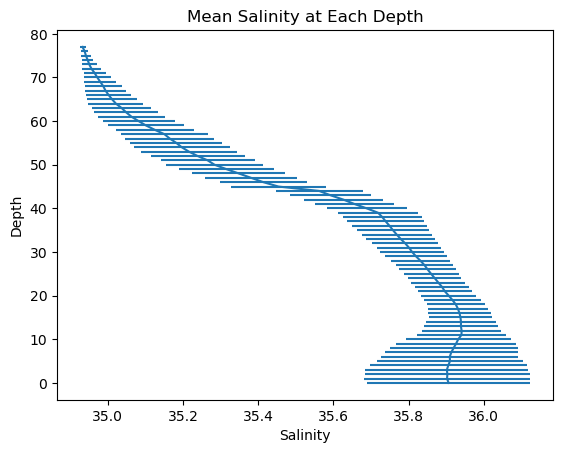

In [75]:
plt.figure()
plt.errorbar(S_mean,levels,xerr=S_std)
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.title('Mean Salinity at Each Depth')


Text(0.5, 1.0, 'Mean Pressure at Each Depth')

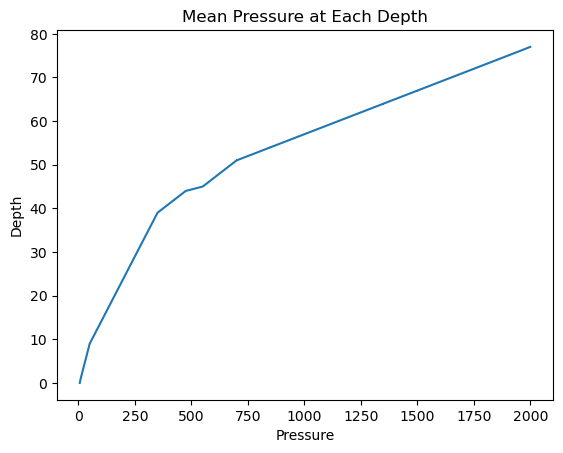

In [76]:
plt.figure()
plt.errorbar(P_mean,levels,xerr=P_std)
plt.xlabel('Pressure')
plt.ylabel('Depth')
plt.title('Mean Pressure at Each Depth')


2.7 Create a scatter plot of the lon, lat positions of the ARGO float.
Use the plt.scatter function.

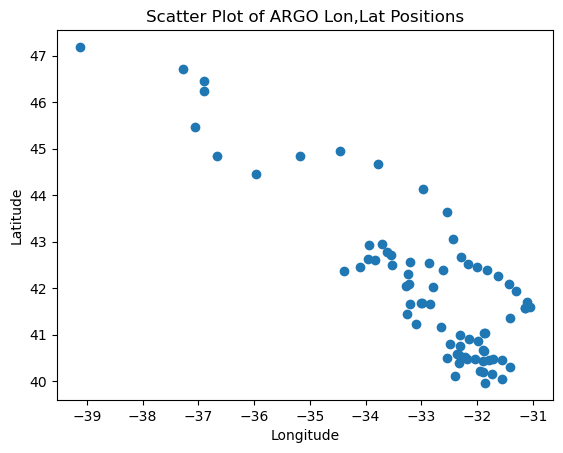

In [79]:
plt.figure()
plt.scatter(lon,lat)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of ARGO Lon,Lat Positions')
plt.show()